**Import libraries**

In [14]:
## Load packages and cleaned data
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt

os.chdir('/Users/gracewang/Documents/Hertie/Data Structures & Algorithms/project-chaggg')

# ── Load cleaned data ─────────────────────────────────────────────────────────
df = pd.read_csv('data/cleaned/chicago_crimes_cleaned.csv', low_memory=False)

# district was saved as Int64 — restore it
df["district"] = pd.to_numeric(df["district"], errors="coerce").astype("Int64")

# Drop rows missing district or arrest
df = df.dropna(subset=["district", "arrest"])

In [11]:
df.shape

(7897540, 26)

                         primary_type  total_count  domestic_count  \
0          OFFENSE INVOLVING CHILDREN        54127           40435   
1                             BATTERY      1444031          770537   
2                            STALKING         5964            3169   
4                       OTHER OFFENSE       494555          184174   
5                          KIDNAPPING         6529            2214   
6                             ASSAULT       535021          156383   
7             CRIMINAL SEXUAL ASSAULT        34699            6693   
9                         SEX OFFENSE        30239            4723   
10                       INTIMIDATION         4804             727   
12                    CRIMINAL DAMAGE       903363          105064   
13                           HOMICIDE        13404             930   
14                              ARSON        13391             801   
15                  CRIMINAL TRESPASS       213543           11162   
16             PUBLI

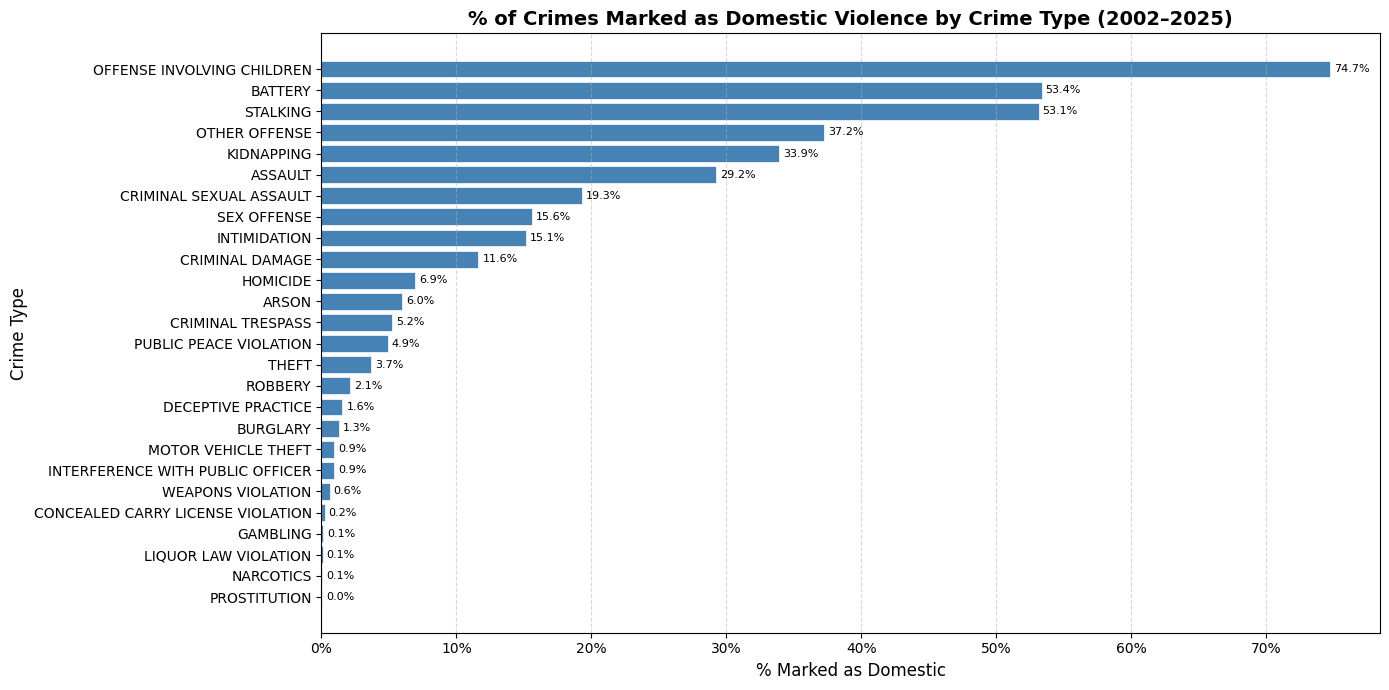

In [18]:
# Plot percentage of each crime type labeled domestic violence

# ── Standardize inconsistent primary_type labels ──────────────────────────────
type_remap = {
    "CRIM SEXUAL ASSAULT": "CRIMINAL SEXUAL ASSAULT",
}

df["primary_type"] = df["primary_type"].replace(type_remap)

# ── Calculate domestic rate by crime type ────────────────────────────────────
domestic_summary = (
    df.groupby("primary_type")
    .agg(
        total_count=("domestic", "count"),
        domestic_count=("domestic", "sum")
    )
    .assign(domestic_rate=lambda x: (x["domestic_count"] / x["total_count"] * 100).round(2))
    .sort_values("domestic_rate", ascending=False)
    .reset_index()
)

domestic_summary = domestic_summary[domestic_summary["total_count"] >= 1000]
print(domestic_summary)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))

bars = ax.barh(
    domestic_summary["primary_type"],
    domestic_summary["domestic_rate"],
    color="steelblue",
    edgecolor="white",
    linewidth=0.5
)

# Annotate each bar with its percentage
for bar, val in zip(bars, domestic_summary["domestic_rate"]):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}%',
        ha="left", va="center", fontsize=8
    )

ax.set_xlabel("% Marked as Domestic", fontsize=12)
ax.set_ylabel("Crime Type", fontsize=12)
ax.set_title("% of Crimes Marked as Domestic Violence by Crime Type (2002–2025)", fontsize=14, fontweight="bold")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.invert_yaxis()  # highest % at the top
ax.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("domestic_rate_by_crime_type.png", dpi=150)
plt.show()

In [19]:
# Table summarizing arrest rate by crime type

# ── Calculate arrest rate by crime type ──────────────────────────────────────
arrest_summary = (
    df.groupby("primary_type")
    .agg(
        total_count=("arrest", "count"),
        arrest_count=("arrest", "sum")
    )
    .assign(arrest_rate=lambda x: (x["arrest_count"] / x["total_count"] * 100).round(2))
    .sort_values("total_count", ascending=False)
    .reset_index()
)

# ── Rename columns for display ────────────────────────────────────────────────
arrest_summary.columns = ["Crime Type", "Total Count", "Arrest Count", "Arrest Rate %"]

# ── Format columns ────────────────────────────────────────────────────────────
arrest_summary["Total Count"]   = arrest_summary["Total Count"].apply(lambda x: f'{x:,}')
arrest_summary["Arrest Count"]  = arrest_summary["Arrest Count"].apply(lambda x: f'{x:,}')
arrest_summary["Arrest Rate %"] = arrest_summary["Arrest Rate %"].apply(lambda x: f'{x:.2f}%')

print(arrest_summary.to_string(index=False))

# ── Save to CSV ────────────────────────────────────────────────────
arrest_summary.to_csv('data/cleaned/arrest_rate_by_crime_type.csv', index=False)

                       Crime Type Total Count Arrest Count Arrest Rate %
                            THEFT   1,680,189      178,490        10.62%
                          BATTERY   1,444,031      312,813        21.66%
                  CRIMINAL DAMAGE     903,363       57,725         6.39%
                        NARCOTICS     701,894      697,186        99.33%
                          ASSAULT     535,021      107,178        20.03%
                    OTHER OFFENSE     494,555       87,681        17.73%
                         BURGLARY     420,049       23,791         5.66%
              MOTOR VEHICLE THEFT     403,920       29,063         7.20%
               DECEPTIVE PRACTICE     355,017       42,658        12.02%
                          ROBBERY     295,738       27,373         9.26%
                CRIMINAL TRESPASS     213,543      143,391        67.15%
                WEAPONS VIOLATION     120,970       87,594        72.41%
                     PROSTITUTION      63,770      

           primary_type  incident_count
30                THEFT         1680189
2               BATTERY         1444031
5       CRIMINAL DAMAGE          903363
17            NARCOTICS          701894
1               ASSAULT          535021
22        OTHER OFFENSE          494555
3              BURGLARY          420049
16  MOTOR VEHICLE THEFT          403920
8    DECEPTIVE PRACTICE          355017
27              ROBBERY          295738


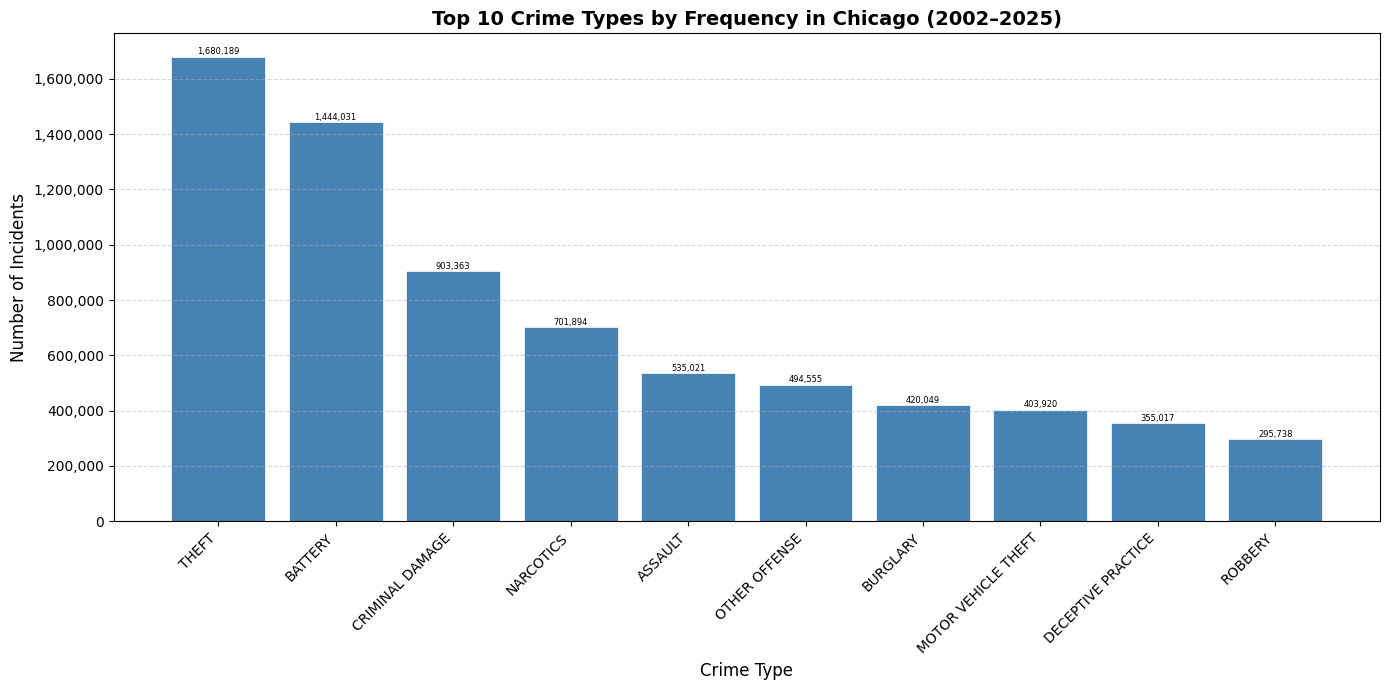

In [20]:
# Top 10 crime types by frequency

# ── Count crimes by primary type, sorted descending ──────────────────────────
type_counts = (
    df.groupby("primary_type")
    .size()
    .reset_index(name="incident_count")
    .sort_values("incident_count", ascending=False)
    .head(10)
)

print(type_counts)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))

bars = ax.bar(
    type_counts["primary_type"],
    type_counts["incident_count"],
    color="steelblue",
    edgecolor="white",
    linewidth=0.5
)

# Annotate each bar with its count
for bar, val in zip(bars, type_counts["incident_count"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f'{int(val):,}',
        ha="center", va="bottom", fontsize=6
    )

ax.set_xlabel("Crime Type", fontsize=12)
ax.set_ylabel("Number of Incidents", fontsize=12)
ax.set_title("Top 10 Crime Types by Frequency in Chicago (2002–2025)", fontsize=14, fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("crimes_by_primary_type.png", dpi=150)
plt.show()

    month  avg_incidents month_name
0       1   25529.666667        Jan
1       2   22677.375000        Feb
2       3   26812.250000        Mar
3       4   26704.708333        Apr
4       5   29201.666667        May
5       6   29186.208333        Jun
6       7   30698.625000        Jul
7       8   30318.458333        Aug
8       9   28581.125000        Sep
9      10   28803.958333        Oct
10     11   25876.875000        Nov
11     12   24673.250000        Dec


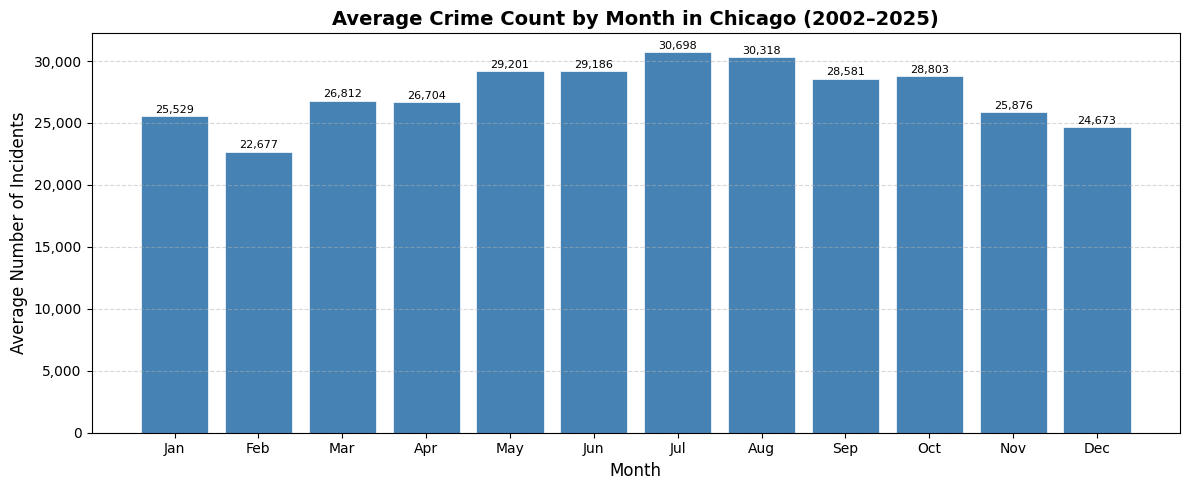

In [22]:
# Plot avg crimes per month

#  ── Extract month from date ───────────────────────────────────────────────────
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.month

# ── Count crimes per year-month, then average across years ───────────────────
monthly_avg = (
    df.groupby(["year", "month"])
    .size()
    .reset_index(name="incident_count")
    .groupby("month")["incident_count"]
    .mean()
    .reset_index(name="avg_incidents")
)

# ── Replace month numbers with names ─────────────────────────────────────────
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
monthly_avg["month_name"] = monthly_avg["month"].apply(lambda x: month_names[x - 1])

print(monthly_avg)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(
    monthly_avg["month_name"],
    monthly_avg["avg_incidents"],
    color="steelblue",
    edgecolor="white",
    linewidth=0.5
)

# Annotate each bar with its value
for bar, val in zip(bars, monthly_avg["avg_incidents"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f'{int(val):,}',
        ha="center", va="bottom", fontsize=8
    )

ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Average Number of Incidents", fontsize=12)
ax.set_title("Average Crime Count by Month in Chicago (2002–2025)", fontsize=14, fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("avg_crimes_by_month.png", dpi=150)
plt.show()

    year  incident_count
0   2002          471530
1   2003          472042
2   2004          467210
3   2005          449928
4   2006          445564
5   2007          435706
6   2008          419858
7   2009          385965
8   2010          369984
9   2011          351304
10  2012          335466
11  2013          306413
12  2014          273755
13  2015          257908
14  2016          267224
15  2017          264935
16  2018          263523
17  2019          259171
18  2020          207971
19  2021          202869
20  2022          234882
21  2023          261245
22  2024          257538
23  2025          235549


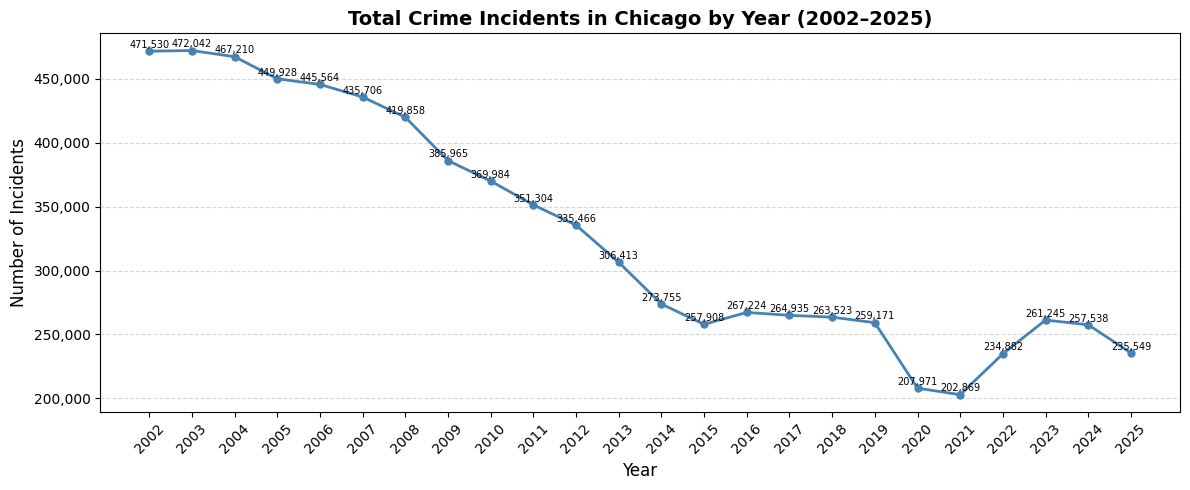

In [23]:
# Plot crime count by year

# ── Group by year and count incidents ────────────────────────────────────────
yearly_counts = (
    df.groupby("year")
    .size()
    .reset_index(name="incident_count")
    .sort_values("year")
)

print(yearly_counts)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    yearly_counts["year"],
    yearly_counts["incident_count"],
    color="steelblue",
    linewidth=2,
    marker="o",
    markersize=5
)

# Annotate each point with its count
for _, row in yearly_counts.iterrows():
    ax.text(
        row["year"],
        row["incident_count"] + 1000,
        f'{int(row["incident_count"]):,}',
        ha="center", va="bottom", fontsize=7
    )

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Number of Incidents", fontsize=12)
ax.set_title("Total Crime Incidents in Chicago by Year (2002–2025)", fontsize=14, fontweight="bold")
ax.set_xticks(yearly_counts["year"])
plt.xticks(rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("total_crimes_by_year.png", dpi=150)
plt.show()

    district  total_crimes  total_arrests  arrest_rate
0          1        334653          87205    26.058335
1          2        364253          85388    23.441948
2          3        401941          97866    24.348350
3          4        450491          96609    21.445267
4          5        347000          85098    24.523919
5          6        465280         114910    24.696957
6          7        448272         122828    27.400328
7          8        531744         115424    21.706686
8          9        383013         101310    26.450799
9         10        340506         104370    30.651442
10        11        501991         204057    40.649534
11        12        398460          83143    20.866084
12        14        299881          58578    19.533748
13        15        332906         124793    37.485957
14        16        265166          47401    17.875972
15        17        228765          45186    19.752147
16        18        358597          78928    22.010223
17        

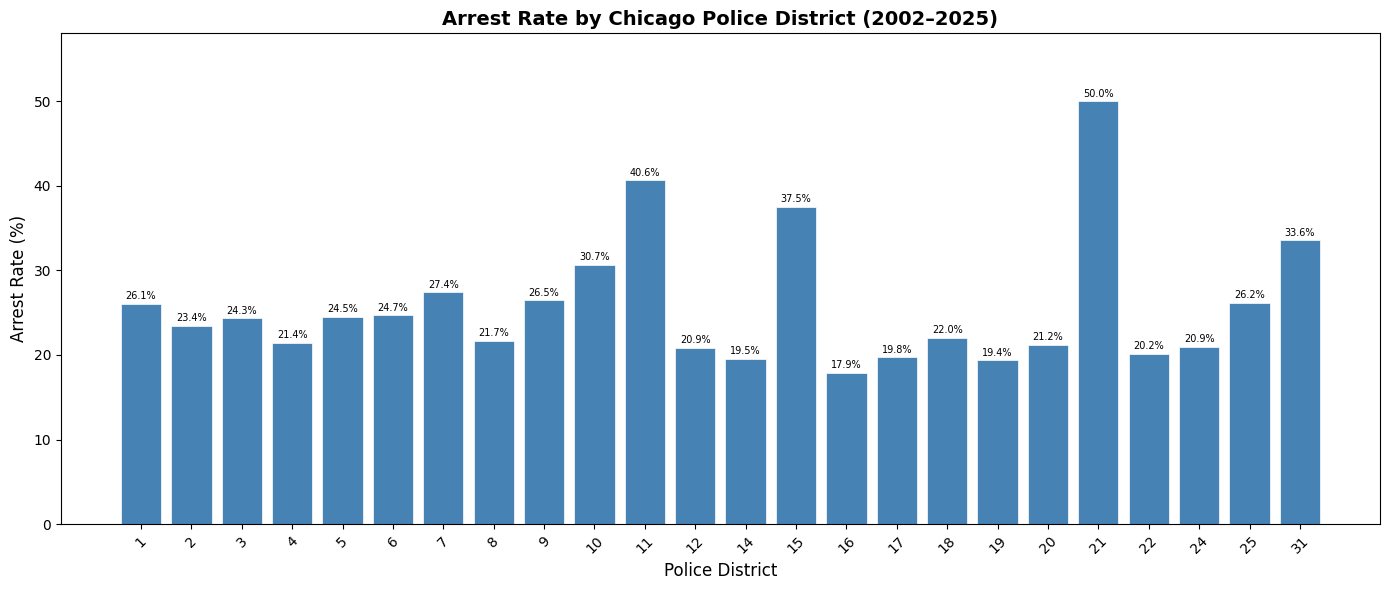

In [24]:
## Plot arrest rates by district into bar chart


# ── Calculate arrest rate per district ───────────────────────────────────────
summary = (
    df.groupby("district")
    .agg(
        total_crimes=("arrest", "count"),
        total_arrests=("arrest", "sum")
    )
    .assign(arrest_rate=lambda x: x["total_arrests"] / x["total_crimes"] * 100)
    .sort_values("district")
    .reset_index()
)

print(summary)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.bar(
    summary["district"].astype(str),
    summary["arrest_rate"],
    color="steelblue",
    edgecolor="white",
    linewidth=0.5
)

# Annotate each bar with its rate
for bar, rate in zip(bars, summary["arrest_rate"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{rate:.1f}%",
        ha="center", va="bottom", fontsize=7
    )

ax.set_xlabel("Police District", fontsize=12)
ax.set_ylabel("Arrest Rate (%)", fontsize=12)
ax.set_title("Arrest Rate by Chicago Police District (2002–2025)", fontsize=14, fontweight="bold")
ax.set_ylim(0, summary["arrest_rate"].max() + 8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("arrest_rate_by_district.png", dpi=150)
plt.show()

    year  incident_count
1   2002           82594
2   2003           76585
3   2004           75026
4   2005           70724
5   2006           69208
6   2007           70434
7   2008           69368
8   2009           65273
9   2010           61387
10  2011           58253
11  2012           55576
12  2013           52074
13  2014           47546
14  2015           49005
15  2016           50842
16  2017           50510
17  2018           51881
18  2019           51238
19  2020           46322
20  2021           47927
21  2022           44988
22  2023           47075
23  2024           47588


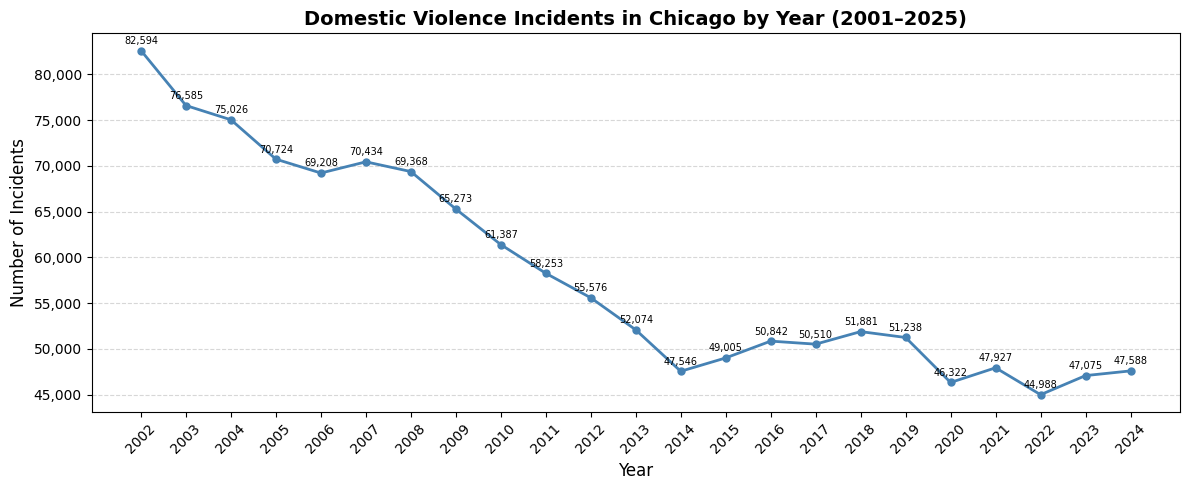

In [ ]:
## Plot annual domestic violence incident count over time (2002–2025)

import pandas as pd
import matplotlib.pyplot as plt

# ── Load cleaned data ─────────────────────────────────────────────────────────
df = pd.read_csv('data/cleaned/chicago_crimes_cleaned.csv', low_memory=False)

# ── Filter for domestic violence crimes ──────────────────────────────────────
domestic = df[df["domestic"] == True]

# ── Group by year and count incidents ────────────────────────────────────────
yearly_counts = (
    domestic.groupby("year")
    .size()
    .reset_index(name="incident_count")
    .sort_values("year")
)

# Drop 2001 (high missing data) and 2025 (incomplete year)
yearly_counts = yearly_counts[yearly_counts["year"].between(2002, 2024)]

print(yearly_counts)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    yearly_counts["year"],
    yearly_counts["incident_count"],
    color="steelblue",
    linewidth=2,
    marker="o",
    markersize=5
)

# Annotate each point with its count
for _, row in yearly_counts.iterrows():
    ax.text(
        row["year"],
        row["incident_count"] + 500,
        f'{int(row["incident_count"]):,}',
        ha="center", va="bottom", fontsize=7
    )

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Number of Incidents", fontsize=12)
ax.set_title("Domestic Violence Incidences in Chicago by Year (2002–2025)", fontsize=14, fontweight="bold")
ax.set_xticks(yearly_counts["year"])
plt.xticks(rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("domestic_violence_by_year.png", dpi=150)

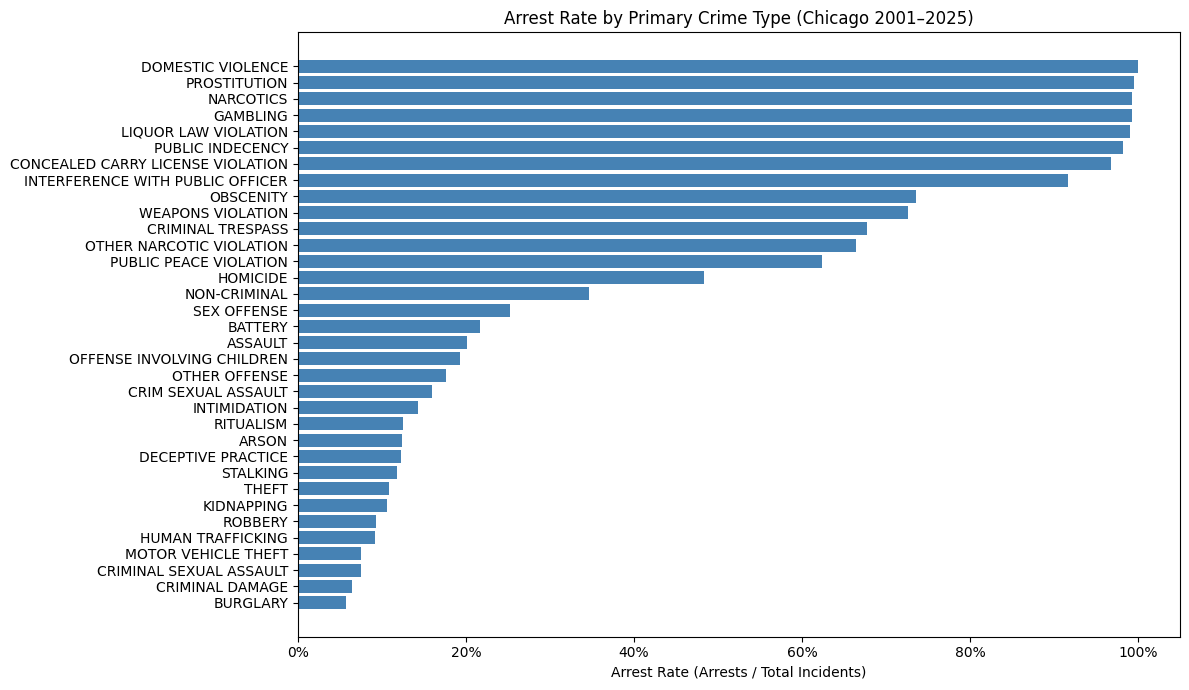

In [ ]:
# Arrest rates by primary crime type
arrest_rates = (
    df.groupby("primary_type")
    .agg(total=("arrest", "count"), arrests=("arrest", "sum"))
    .assign(arrest_rate=lambda x: x["arrests"] / x["total"])
    .sort_values("arrest_rate", ascending=False)
    .reset_index()
)

# Plot
fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(arrest_rates["primary_type"], arrest_rates["arrest_rate"], color="steelblue")
ax.invert_yaxis()
ax.set_xlabel("Arrest Rate (Arrests / Total Incidents)")
ax.set_title("Arrest Rate by Primary Crime Type (Chicago 2002–2025)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.tight_layout()
plt.savefig("arrest_rate_by_primary_crime_type.png", dpi=150)
plt.show()

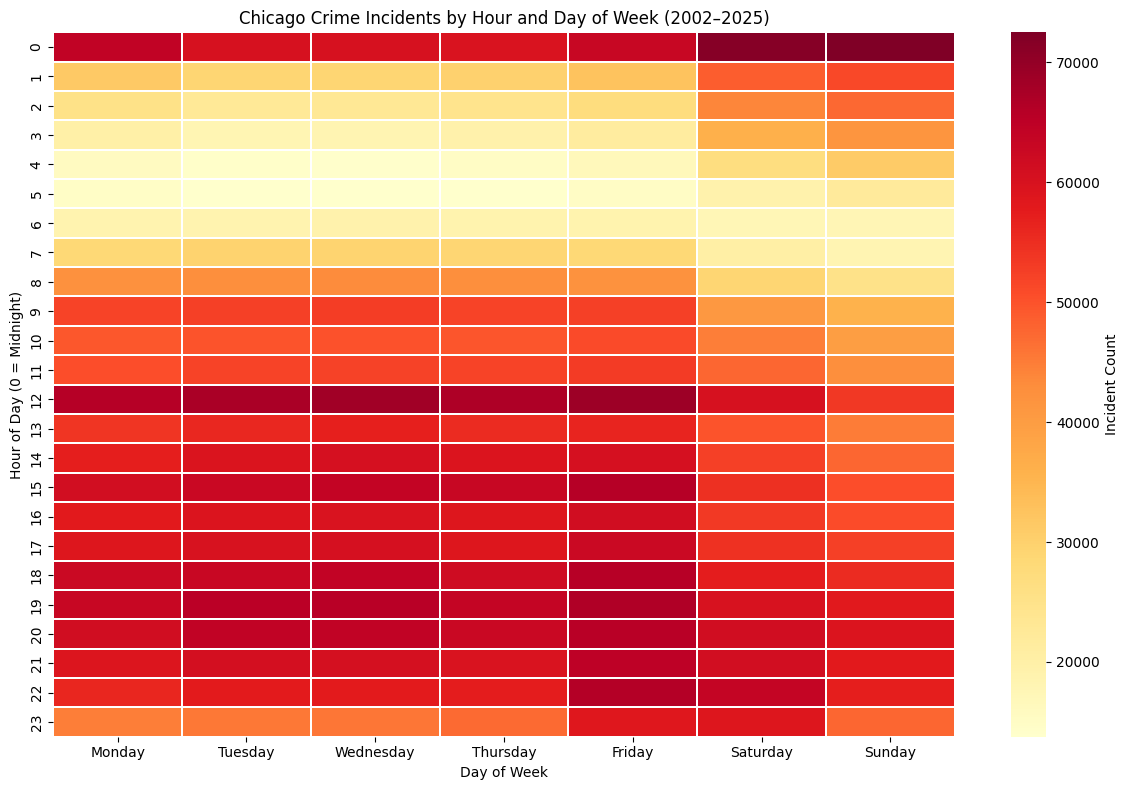

In [25]:
## Plot incident count by time of day (hour) and day of week (M, T, W, Th, etc.)
import seaborn as sns

# Parse date column if not already done
df["Date"] = pd.to_datetime(df["date"])
df["Time"] = pd.to_datetime(df["time"], format="%H:%M:%S")
df["Hour"] = df["Time"].dt.hour
df["DayOfWeek"] = df["Date"].dt.day_name()

# Pivot into hour x day matrix
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
heatmap_data = (
    df.groupby(["Hour", "DayOfWeek"])
    .size()
    .unstack("DayOfWeek")
    .reindex(columns=day_order)
)

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    ax=ax,
    fmt=",",
    annot=False,
    linewidths=0.3,
    cbar_kws={"label": "Incident Count"}
)
ax.set_title("Chicago Crime Incidents by Hour and Day of Week (2002–2025)")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Hour of Day (0 = Midnight)")
plt.tight_layout()
plt.savefig("crimes_by_hour_and_day_of_week.png", dpi=150)
plt.show()